# SIR Model Predictions Visualization

This notebook visualizes the performance of a trained MLP model on SIR simulation data, highlighting prediction accuracy for susceptible (S), infected (I), and recovered (R) compartments.

## Selected β-γ Pair Visualization
We show the model predictions against the true values for selected (β, γ) pairs, along with R² scores for each compartment.

## Composite Plot
Here, we visualize multiple (β, γ) combinations in a single figure grid for a holistic understanding of the model’s behavior.

## Residual Distributions
We plot the residuals (true - predicted) for S, I, and R across all samples to understand prediction errors.


 Evaluation Metrics:

S:
  R²    : 0.6408
  MAE   : 1.10
  RMSE  : 5.64

I:
  R²    : 0.7672
  MAE   : 1.09
  RMSE  : 4.78

R:
  R²    : 0.9747
  MAE   : 0.65
  RMSE  : 2.20


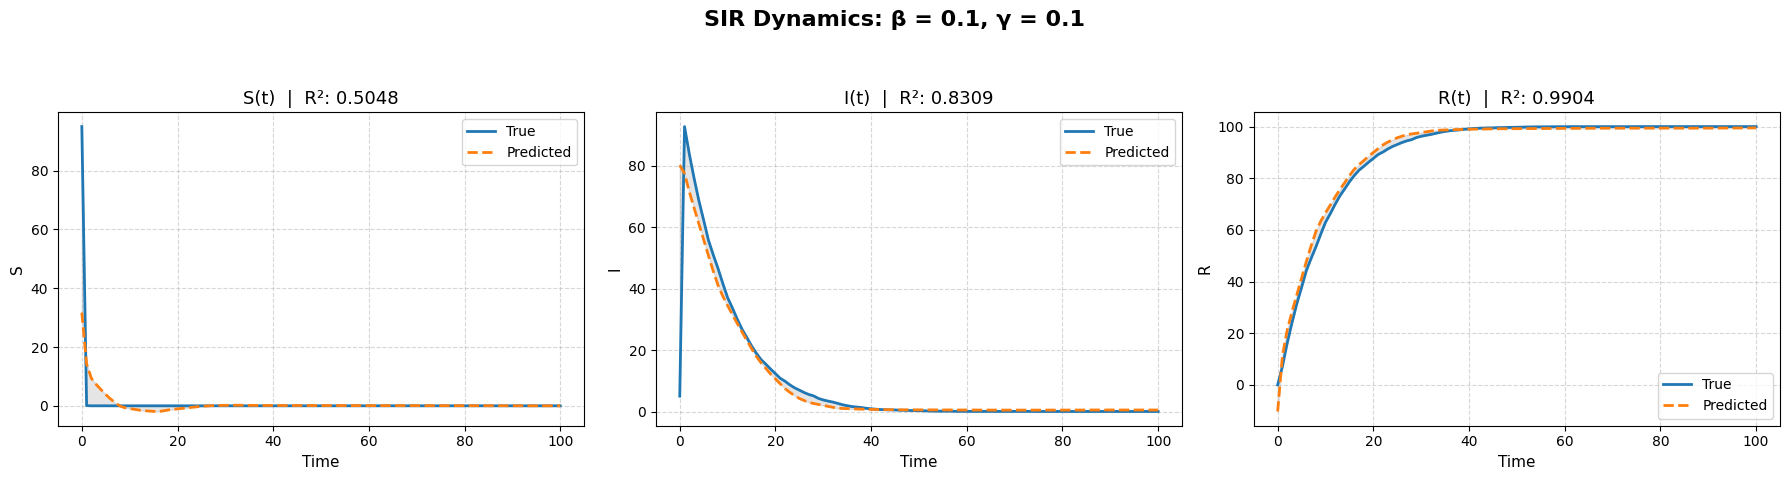

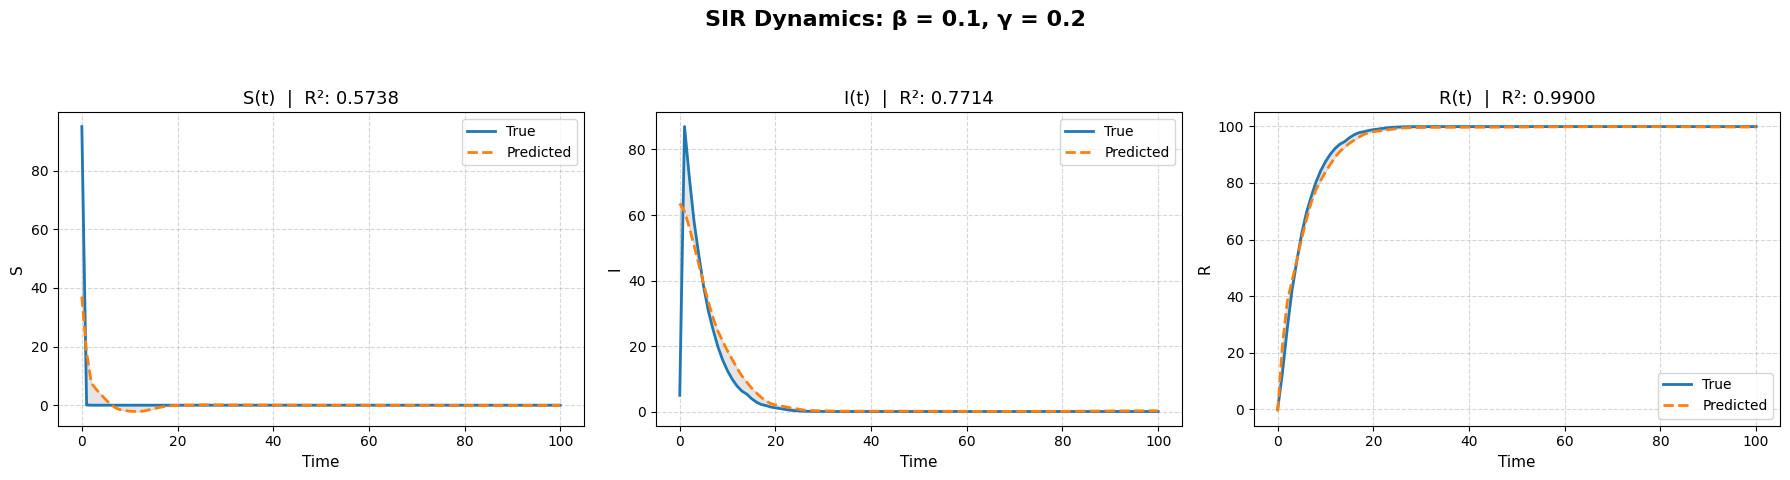

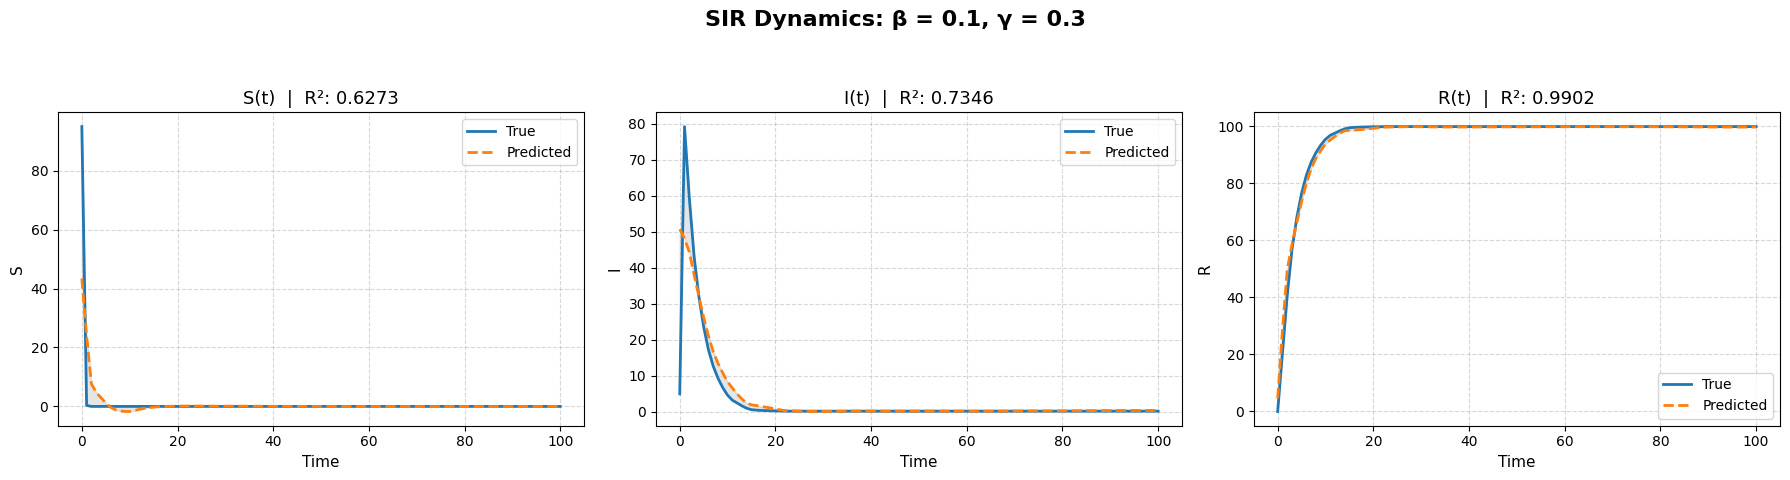

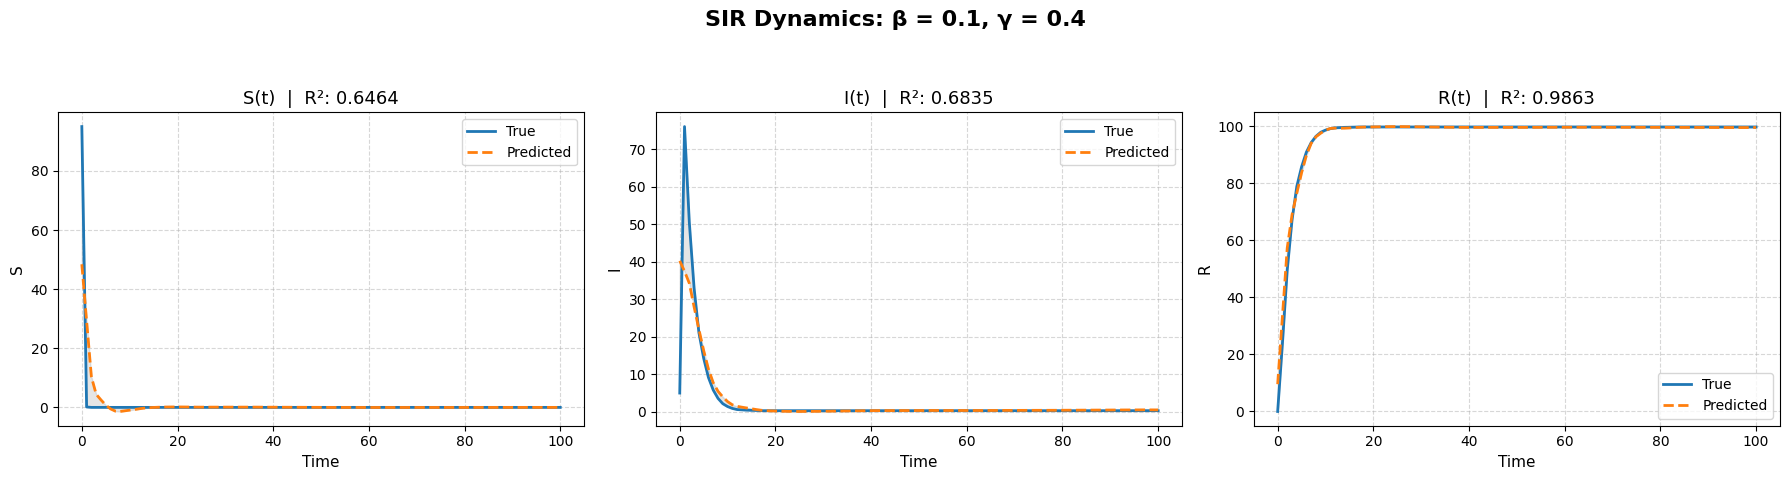

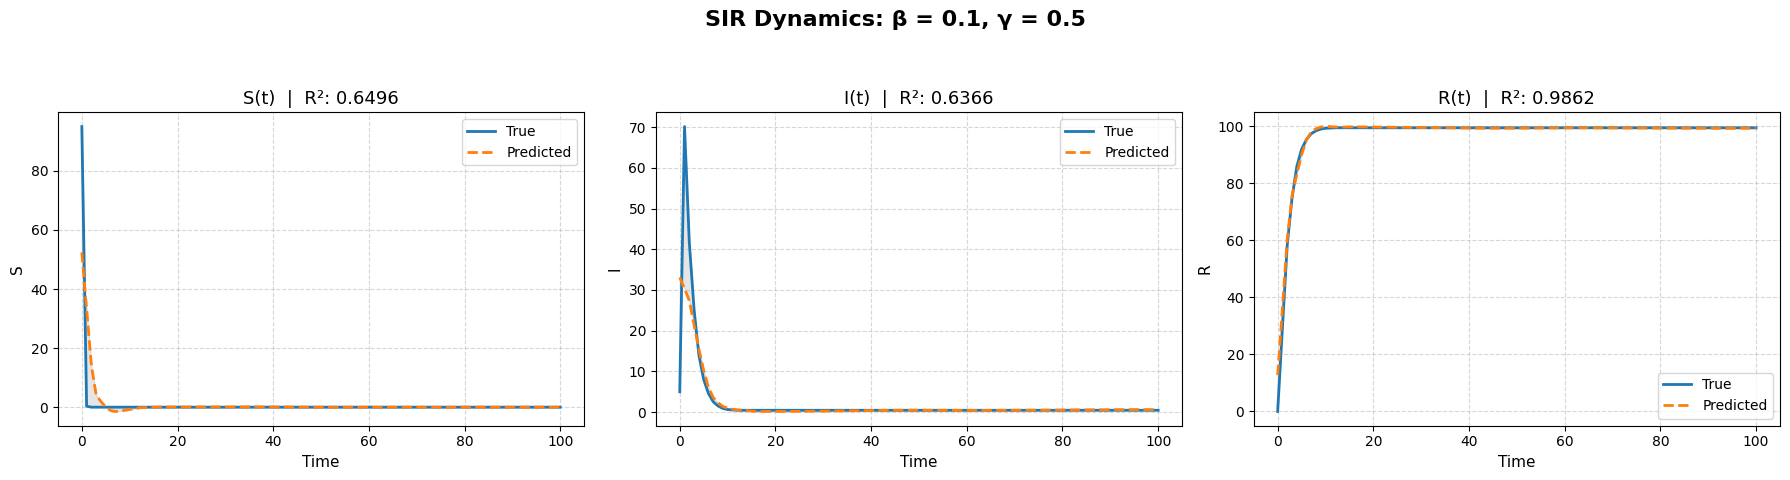

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import argparse
import os

# Load data and model path (modify as needed)
data_path = "../data/processed/sir_mean.csv"
model_path = "../models/sir_mlp.pt"

# Load and preprocess data
df = pd.read_csv(data_path)
X = df[["beta", "gamma", "time"]].values
y = df[["S", "I", "R"]].values

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

# Define Model
class SIRNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 3)
        )
    
    def forward(self, x):
        return self.net(x)

# Load model
model = SIRNet()
model.load_state_dict(torch.load(model_path))
model.eval()

# Make predictions
with torch.no_grad():
    y_pred_scaled = model(X_tensor).numpy()
    y_pred = scaler_y.inverse_transform(y_pred_scaled)

# Evaluation metrics
r2 = [r2_score(y[:, i], y_pred[:, i]) for i in range(3)]
mae = [mean_absolute_error(y[:, i], y_pred[:, i]) for i in range(3)]
rmse = [np.sqrt(mean_squared_error(y[:, i], y_pred[:, i])) for i in range(3)]

print("\n Evaluation Metrics:")
for i, label in enumerate(["S", "I", "R"]):
    print(f"\n{label}:")
    print(f"  R²    : {r2[i]:.4f}")
    print(f"  MAE   : {mae[i]:.2f}")
    print(f"  RMSE  : {rmse[i]:.2f}")

# Create output directory for figures
output_dir = "../figures/sir_predictions"
os.makedirs(output_dir, exist_ok=True)

# Visualization for selected β-γ pairs
cmap = plt.get_cmap("tab10")
unique_pairs = df.groupby(['beta', 'gamma']).groups
pairs_to_plot = list(unique_pairs.items())[:5]

for (beta, gamma), indices in pairs_to_plot:
    idx = list(indices)
    time = df.iloc[idx]["time"].values
    true_vals = y[idx]
    pred_vals = y_pred[idx]
    r2s = [r2_score(true_vals[:, i], pred_vals[:, i]) for i in range(3)]

    plt.figure(figsize=(18, 5))
    for i, label in enumerate(["S", "I", "R"]):
        plt.subplot(1, 3, i + 1)
        plt.plot(time, true_vals[:, i], label="True", color=cmap(0), linewidth=2)
        plt.plot(time, pred_vals[:, i], label="Predicted", color=cmap(1), linestyle="--", linewidth=2)
        plt.fill_between(time, true_vals[:, i], pred_vals[:, i], color='gray', alpha=0.2)
        plt.title(f"{label}(t)  |  R²: {r2s[i]:.4f}", fontsize=13)
        plt.xlabel("Time", fontsize=11)
        plt.ylabel(label, fontsize=11)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend(fontsize=10)

    plt.suptitle(f"SIR Dynamics: β = {beta}, γ = {gamma}", fontsize=16, weight="bold")
    plt.tight_layout(rect=[0, 0.03, 1, 0.92])
    fig_filename = f"sir_pred_beta_{beta:.3f}_gamma_{gamma:.3f}.png".replace(".", "_")
    plt.savefig(os.path.join(output_dir, fig_filename), dpi=300)
    plt.show()


## Residual Distribution and Composite Plots

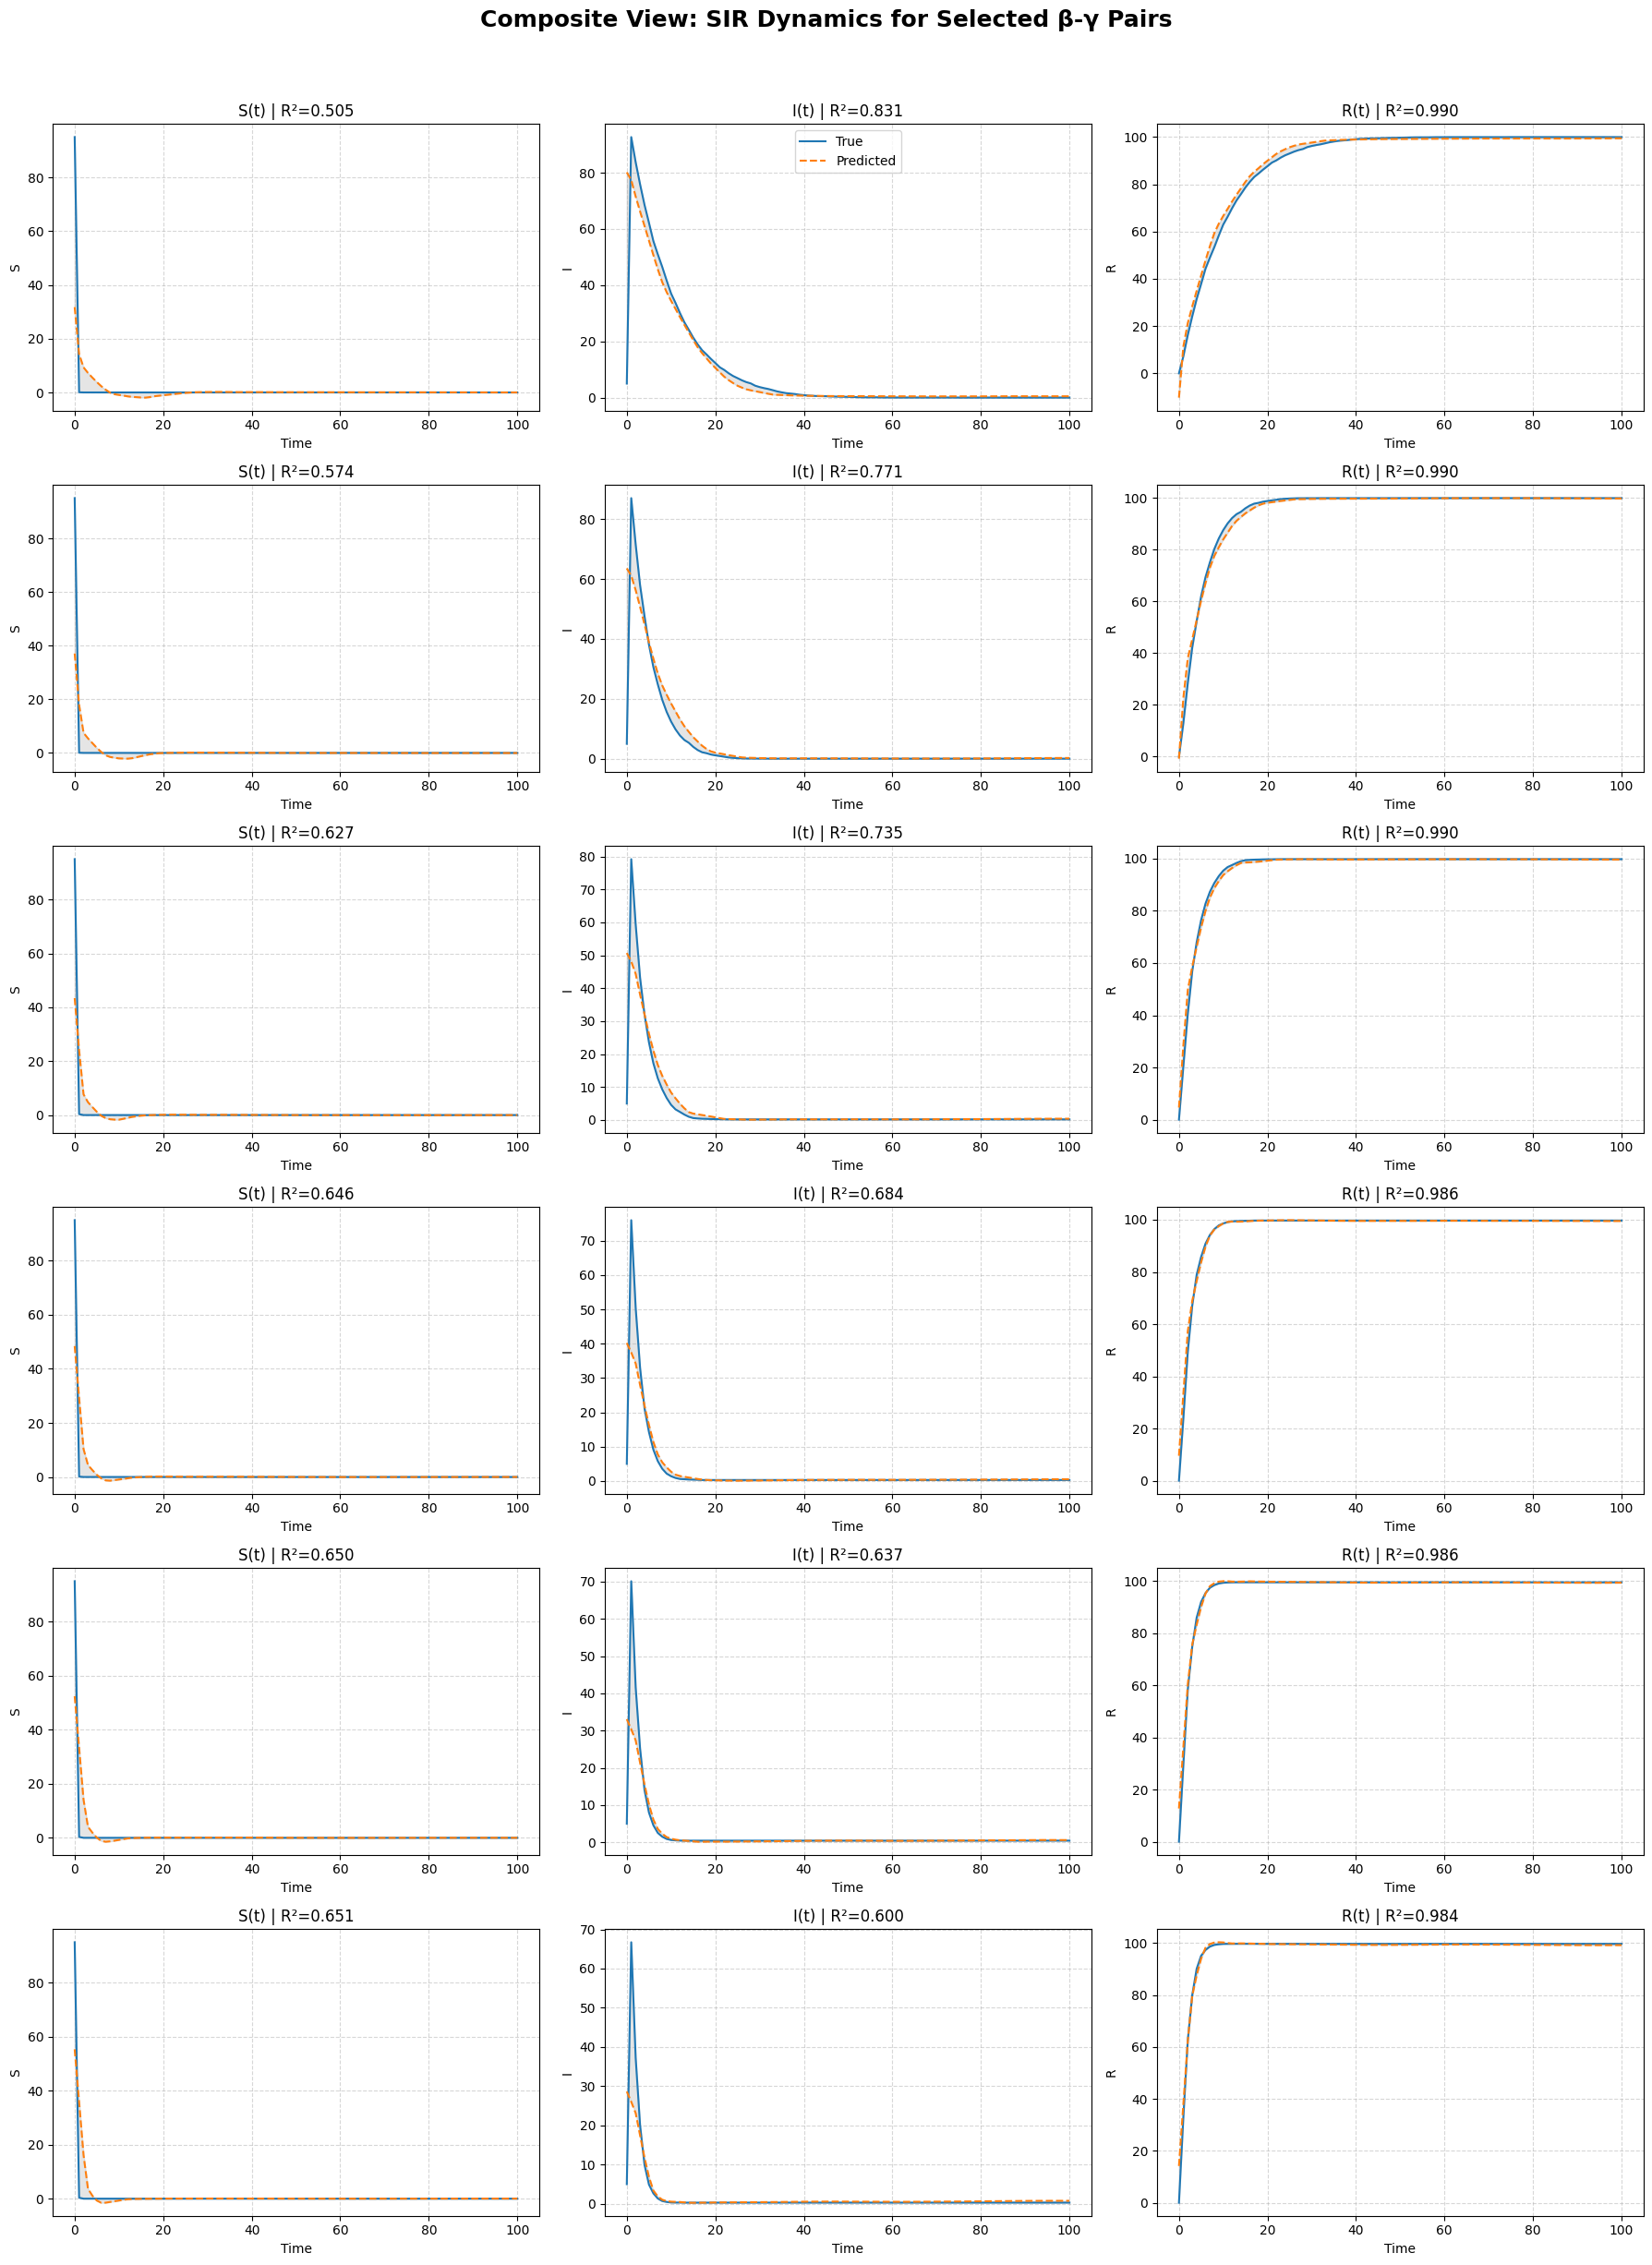

In [2]:

# Composite subplot grid for multiple β-γ pairs
pairs_to_plot = list(unique_pairs.items())[:6]  # adjust as needed
fig, axes = plt.subplots(len(pairs_to_plot), 3, figsize=(18, 4 * len(pairs_to_plot)))

for row, ((beta, gamma), indices) in enumerate(pairs_to_plot):
    idx = list(indices)
    time = df.iloc[idx]["time"].values
    true_vals = y[idx]
    pred_vals = y_pred[idx]
    r2s = [r2_score(true_vals[:, i], pred_vals[:, i]) for i in range(3)]
    
    for col, label in enumerate(["S", "I", "R"]):
        ax = axes[row, col]
        ax.plot(time, true_vals[:, col], label="True", color=cmap(0))
        ax.plot(time, pred_vals[:, col], label="Predicted", color=cmap(1), linestyle="--")
        ax.fill_between(time, true_vals[:, col], pred_vals[:, col], color='gray', alpha=0.2)
        ax.set_title(f"{label}(t) | R²={r2s[col]:.3f}")
        ax.set_xlabel("Time")
        ax.set_ylabel(label)
        ax.grid(True, linestyle='--', alpha=0.5)
        if row == 0 and col == 1:
            ax.legend(loc='upper center')

plt.suptitle("Composite View: SIR Dynamics for Selected β-γ Pairs", fontsize=18, weight="bold", y=1.02)
plt.tight_layout()
plt.show()


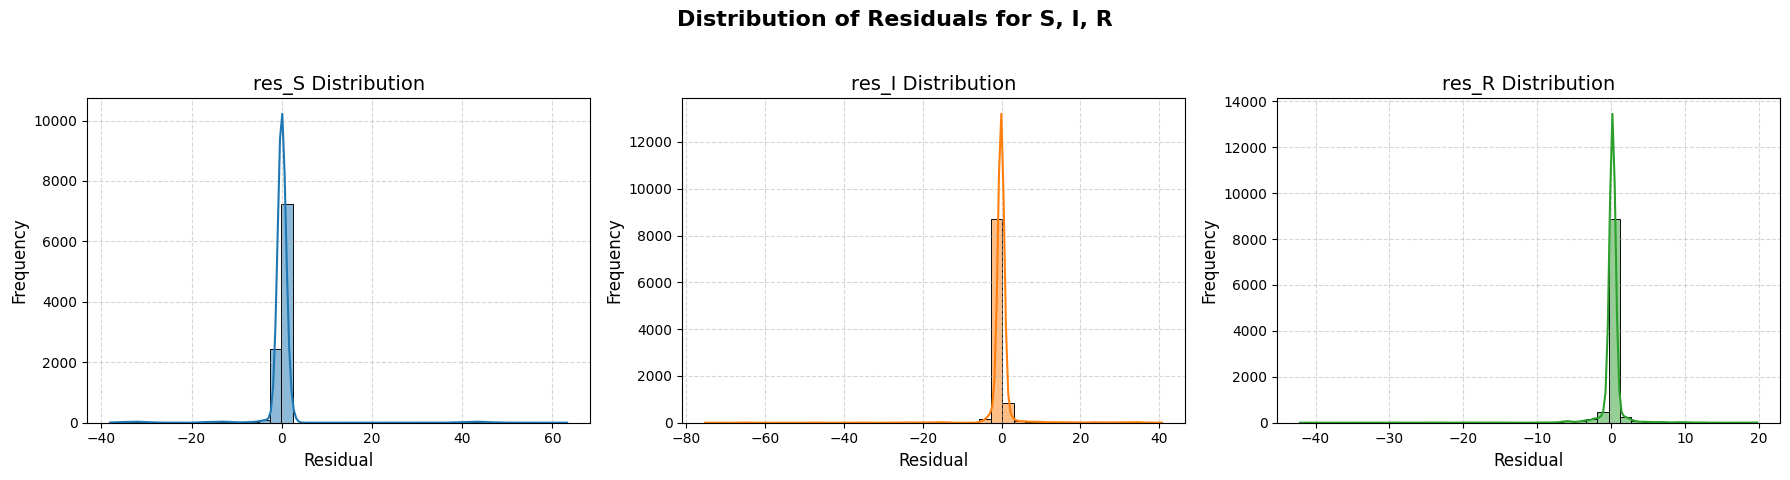

In [3]:
# Residual Distributions 
import seaborn as sns
import matplotlib.pyplot as plt

# Compute residuals (true - predicted)
residuals = y - y_pred
residuals_df = pd.DataFrame(residuals, columns=["res_S", "res_I", "res_R"])

# Plot residual histograms with KDE
plt.figure(figsize=(18, 5))
for i, label in enumerate(["res_S", "res_I", "res_R"]):
    plt.subplot(1, 3, i + 1)
    sns.histplot(residuals_df[label], kde=True, bins=40, color=cmap(i))
    plt.title(f"{label} Distribution", fontsize=14)
    plt.xlabel("Residual", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Distribution of Residuals for S, I, R", fontsize=16, weight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## Interactive Visual Exploration

In [4]:

import ipywidgets as widgets
from IPython.display import display

# Get sorted unique beta and gamma values
beta_values = sorted(df["beta"].unique())
gamma_values = sorted(df["gamma"].unique())

def plot_interactive(beta, gamma):
    indices = unique_pairs.get((beta, gamma), [])
    if len(indices) == 0:
        print("No data for selected pair.")
        return

    idx = list(indices)
    time = df.iloc[idx]["time"].values
    true_vals = y[idx]
    pred_vals = y_pred[idx]

    r2s = [r2_score(true_vals[:, i], pred_vals[:, i]) for i in range(3)]

    plt.figure(figsize=(18, 5))
    for i, label in enumerate(["S", "I", "R"]):
        plt.subplot(1, 3, i + 1)
        plt.plot(time, true_vals[:, i], label="True", color=cmap(0), linewidth=2)
        plt.plot(time, pred_vals[:, i], label="Predicted", color=cmap(1), linestyle="--", linewidth=2)
        plt.fill_between(time, true_vals[:, i], pred_vals[:, i], color='gray', alpha=0.2)
        plt.title(f"{label}(t) | R²: {r2s[i]:.4f}", fontsize=13)
        plt.xlabel("Time", fontsize=11)
        plt.ylabel(label, fontsize=11)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend(fontsize=10)

    plt.suptitle(f"SIR Dynamics: β = {beta}, γ = {gamma}", fontsize=16, weight="bold")
    plt.tight_layout(rect=[0, 0.03, 1, 0.92])
    plt.show()


    plt.figure(figsize=(16, 4))
    for i, label in enumerate(["S", "I", "R"]):
        plt.subplot(1, 3, i + 1)
        plt.plot(time, true_vals[:, i], label="True", color=cmap(0))
        plt.plot(time, pred_vals[:, i], label="Predicted", color=cmap(1), linestyle="--")
        plt.fill_between(time, true_vals[:, i], pred_vals[:, i], color='gray', alpha=0.2)
        plt.title(f"{label}(t) | R²={r2s[i]:.3f}")
        plt.xlabel("Time")
        plt.ylabel(label)
        plt.grid(True, linestyle='--', alpha=0.4)
        plt.legend()
    plt.suptitle(f"Interactive View: β = {beta}, γ = {gamma}", fontsize=16)
    plt.tight_layout()
    plt.show()

# Interactive widgets
beta_widget = widgets.Dropdown(options=beta_values, description='β:')
gamma_widget = widgets.Dropdown(options=gamma_values, description='γ:')

widgets.interact(plot_interactive, beta=beta_widget, gamma=gamma_widget)


interactive(children=(Dropdown(description='β:', options=(np.float64(0.1), np.float64(0.2), np.float64(0.3), n…

<function __main__.plot_interactive(beta, gamma)>

## Conclusion

This notebook demonstrates that a neural network can approximate deterministic SIR dynamics with high accuracy, especially for recovered individuals. Such methods could be extended to other stochastic differential systems.

This serves as a strong base for future work in scientific machine learning, symbolic regression, or neural differential equations.

